# Bernoulli Naive Bayes

In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [9]:
from sklearn.naive_bayes import BernoulliNB

In [10]:
X, y = load_iris(return_X_y=True)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
bnb = BernoulliNB()

In [14]:
y_pred = bnb.fit(X_train, y_train).predict(X_test)

In [15]:
print(y_pred)
y_pred = bnb.predict(X_test)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [16]:
accuracy = accuracy_score(y_test, y_pred)

In [17]:
print("Accuracy:", accuracy)

Accuracy: 0.3


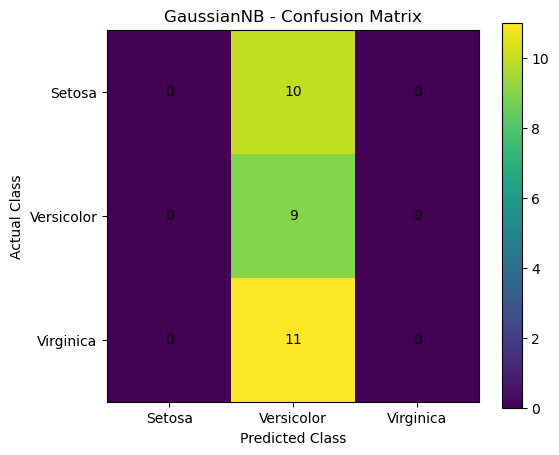

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("GaussianNB - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])
plt.yticks([0, 1, 2], ["Setosa", "Versicolor", "Virginica"])

# Display values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

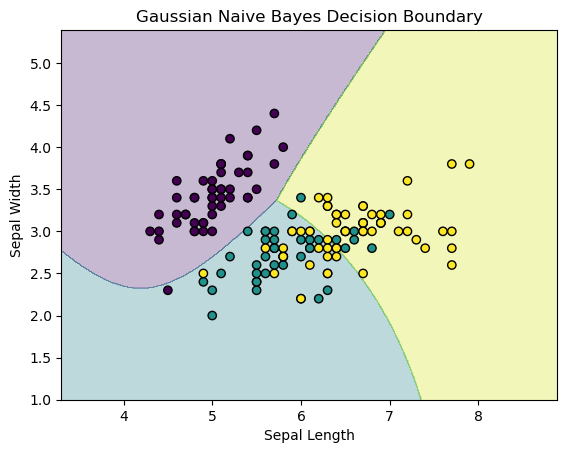

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# Use only feature 0 and feature 1
X_2d = X[:, [0, 1]]

# Train GaussianNB on these 2 features
model_2d = GaussianNB()
model_2d.fit(X_2d, y)

# Create grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Predict grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_2d.predict(grid)
Z = Z.reshape(xx.shape)

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Data points
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    edgecolor="k"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Gaussian Naive Bayes Decision Boundary")
plt.show()